In [ ]:
# Dependencies, Seeding, and Hardware Check

!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib seaborn

import os
import random
import numpy as np
import pandas as pd
import torch
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 50)
print(f"✅ Device active: {device}")
if device.type == 'cuda':
    print(f"✅ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 50)


Mounted at /content/drive
✅ Device active: cuda
✅ GPU Name: Tesla T4
✅ VRAM Available: 15.64 GB


In [ ]:
#Dataset Loading and Validation

dataset_path = '/content/drive/My Drive/424 Project/Bengali_Banglish_80K_Dataset.csv'

print(f"Loading dataset from: {dataset_path}...")
df_raw = pd.read_csv(dataset_path)

print("\n--- Raw Dataset Overview ---")
print(f"Total rows: {df_raw.shape[0]:,}")
print(f"Columns: {list(df_raw.columns)}")

# Isolate the required columns and drop explicitly missing Banglish rows
df = df_raw[['Banglish', 'Label', 'Bengali']].copy()
initial_len = len(df)
df = df.dropna(subset=['Banglish', 'Label'])
df = df[df['Banglish'].str.strip() != ''].reset_index(drop=True)

print(f"\nDropped {initial_len - len(df)} rows with missing or empty Banglish text.")
print(f"Working dataset size: {len(df):,}")

print("\n--- Label Distribution ---")
print(df['Label'].value_counts())


Loading dataset from: /content/drive/My Drive/424 Project/Bengali_Banglish_80K_Dataset.csv...

--- Raw Dataset Overview ---
Total rows: 80,098
Columns: ['Bengali', 'Label', 'Banglish']

Dropped 4 rows with missing or empty Banglish text.
Working dataset size: 80,094

--- Label Distribution ---
Label
joy         17836
sadness     16309
anger       15179
disgust     13098
surprise    10107
fear         7565
Name: count, dtype: int64


In [ ]:
# Cell 3: Text Preprocessing & Normalization
import re

canonical_dict = {
    # GOOD / LOVE
    'valo': 'bhalo', 'balo': 'bhalo', 'vhalo': 'bhalo', 'valoi': 'bhalo', 'bhlo': 'bhalo', 'bhaloo': 'bhalo', 'vallage': 'bhalolage',
    'valobashi': 'bhalobashi', 'balobasi': 'bhalobashi', 'valobaschi': 'bhalobashi', 'balbasi': 'bhalobashi', 'vlobasi': 'bhalobashi', 'bhalobasi': 'bhalobashi',
    'valobasha': 'bhalobasha', 'balobasa': 'bhalobasha', 'bhalobasa': 'bhalobasha', 'vlobasa': 'bhalobasha',
    'valobese': 'bhalobese', 'valobeshe': 'bhalobeshe', 'balobeshe': 'bhalobeshe',

    # FEAR
    'voy': 'bhoy', 'bhoi': 'bhoy', 'voe': 'bhoy',
    'voyonkor': 'bhoyonkor', 'voyanok': 'bhoyonkor', 'voianok': 'bhoyonkor', 'voionkor': 'bhoyonkor',
    'vitu': 'bhitu', 'vit': 'bhit',

    # PAIN / SAD
    'koshto': 'kosto', 'kostho': 'kosto', 'koshtho': 'kosto', 'koshtto': 'kosto', 'kashto': 'kosto', 'kst': 'kosto', 'ksto': 'kosto',
    'dukkho': 'dukho', 'dukko': 'dukho', 'dukhho': 'dukho', 'dukh': 'dukho', 'dukkhito': 'dukhito', 'dukhi': 'dukhito',
    'kanna': 'kanna', 'kadte': 'kadte', 'kade': 'kade',
    'kharap': 'kharap', 'krap': 'kharap', 'kharab': 'kharap',

    # HAPPY
    'khusi': 'khushi', 'khush': 'khushi', 'kushi': 'khushi', 'kusi': 'khushi',
    'hasi': 'hashi', 'hashchi': 'hashchi', 'haschi': 'hashchi', 'hese': 'hese', 'heyshe': 'hese',
    'anondo': 'anondo', 'moza': 'moja',

    # ANGER
    'raag': 'rago', 'rag': 'rago', 'ragi': 'ragi', 'rege': 'rege', 'raga': 'rago',
    'krodh': 'krodh', 'krod': 'krodh',

    # DISGUST
    'ghrinna': 'ghrina', 'grinna': 'ghrina', 'ghinna': 'ghrina', 'ginna': 'ghrina',
    'birokto': 'birokto', 'biroktho': 'birokto', 'biroktikor': 'biroktikor', 'virokto': 'birokto',
    'nongra': 'nongra', 'nogra': 'nongra', 'faltu': 'faltu', 'baje': 'baje',

    # SURPRISE
    'obakh': 'obak', 'ovak': 'obak', 'obak': 'obak', 'abak': 'obak',
    'aschorjo': 'aschorjo', 'aschorjho': 'aschorjo', 'assorjo': 'aschorjo',

    # PRONOUNS & VERBS & STOP WORDS
    'ami': 'ami', 'amr': 'amar', 'amaro': 'amar', 'amake': 'amake', 'amk': 'amake', 'amke': 'amake', 'amay': 'amay',
    'tui': 'tui', 'toke': 'toke', 'tk': 'tk', 'tr': 'tor', 'tor': 'tor',
    'tumi': 'tumi', 'tmr': 'tomar', 'tomr': 'tomar', 'tmk': 'tomake', 'tomke': 'tomake',
    'apni': 'apni', 'apnar': 'apnar', 'apnake': 'apnake',
    'se': 'se', 'tar': 'tar', 'take': 'take',
    'akhon': 'ekhon', 'ekon': 'ekhon', 'ekhn': 'ekhon', 'akhn': 'ekhon',
    'kno': 'keno', 'ken': 'keno', 'knoo': 'keno',
    'korte': 'korte', 'bolte': 'bolte', 'kore': 'kore', 'kre': 'kore', 'korche': 'korche', 'korse': 'korche',
    'korbo': 'korbo', 'krbo': 'korbo', 'krtesi': 'korchi', 'korsi': 'korchi',

    # === NEW ADDITIONS BASED ON OUR OBSERVATIONS ===
    'kinto': 'kintu', 'kntu': 'kintu',
    'jonjo': 'jonno', 'jnno': 'jonno', 'jonn': 'jonno',
    'kisu': 'kichu', 'onek': 'onek', 'onk': 'onek', 'theke': 'theke', 'teke': 'theke'
}

def clean_banglish(text):
    if not isinstance(text, str): return ''
    text = text.lower().strip()
    text = re.sub(r'[\u0980-\u09FF]', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b[a-z]\b', '', text)
    text = re.sub(r'\d+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_banglish(text):
    if not isinstance(text, str): return text

    # 1. Apply canonical dictionary mapping
    for variant, canonical in canonical_dict.items():
        text = re.sub(r'\b' + re.escape(variant) + r'\b', canonical, text)

    # 2. Fix the "j" doubling anomaly for N's (e.g., konja -> konna, bnj -> bnn)
    text = re.sub(r'nj', 'nn', text)

    # 3. Catch-all for v -> bh in remaining vowel contexts
    text = re.sub(r'\bv([aeiou])', r'bh\1', text)

    return text

print("Step 1: Cleaning raw text (removing digits, specials)...")
df['text_clean'] = df['Banglish'].apply(clean_banglish)

print("Step 2: Applying phonetic normalization dictionary...")
df['text_normalized'] = df['text_clean'].apply(normalize_banglish)

initial_len = len(df)
df = df[df['text_normalized'].str.strip() != ''].reset_index(drop=True)
print(f"Dropped {initial_len - len(df)} rows that became empty after cleaning.")

label_mapping = {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}
label_names = list(label_mapping.keys())
df['label_id'] = df['Label'].map(label_mapping)

print("Preprocessing Complete. First 5 normalized samples:")
print(df[['Banglish', 'text_normalized', 'Label']].head())


Step 1: Cleaning raw text (removing digits, specials)...
Step 2: Applying phonetic normalization dictionary...
Dropped 7 rows that became empty after cleaning.
Preprocessing Complete. First 5 normalized samples:
                                            Banglish  \
0  ekhane kaoke kobor diyo na tahole tomader pori...   
1  kinto voy kiser theke ami jantamna kinto amar ...   
2  kronavairas theke srishto rog covid 19 bishbob...   
3  citao tar dike egote sahosh pacche na dudiner ...   
4  rani meri tiudrer pretatma etaaj ceshta korlam...   

                                     text_normalized Label  
0  ekhane kaoke kobor diyo na tahole tomader pori...  fear  
1  kintu bhoy kiser theke ami jantamna kintu amar...  fear  
2  kronavairas theke srishto rog covid bishbobjap...  fear  
3  citao tar dike egote sahosh pacche na dudiner ...  fear  
4  rani meri tiudrer pretatma etaaj ceshta korlam...  fear  


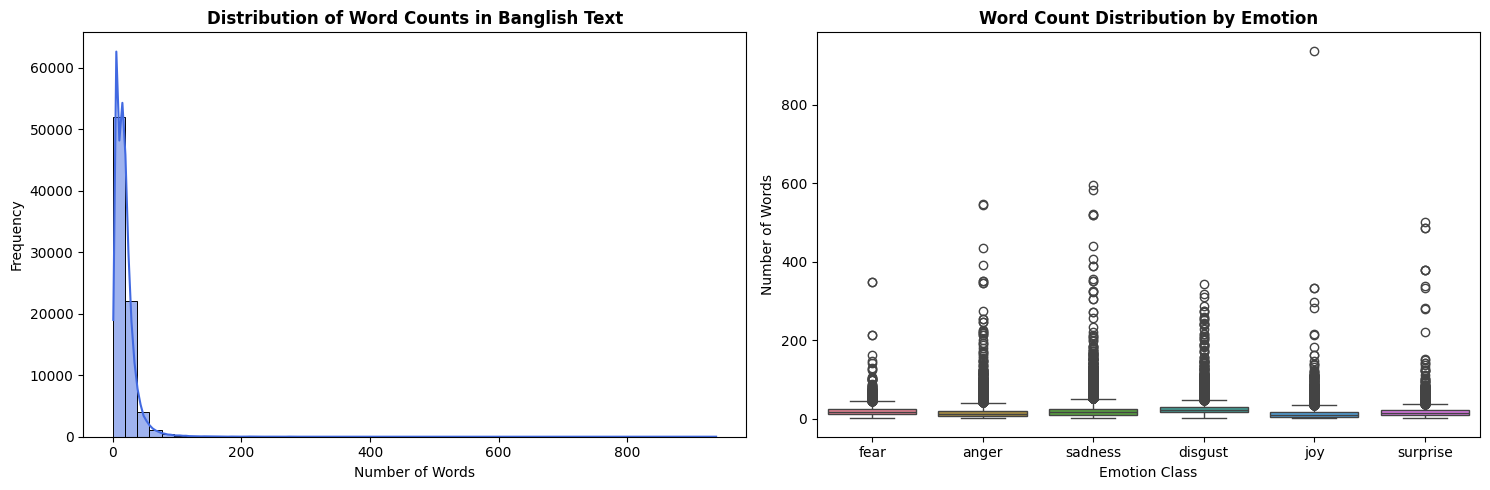

--- Text Length Metrics ---
Mean word count: 18.51
Median word count: 15.00
95th percentile word count: 44
Max word count: 938


In [ ]:
# Cell 4: Word Count Visualization
import matplotlib.pyplot as plt
import seaborn as sns

df['word_count'] = df['text_normalized'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Overall Distribution
sns.histplot(df['word_count'], bins=50, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Distribution of Word Counts in Banglish Text', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# 2. Boxplot by Emotion Class
sns.boxplot(x='Label', y='word_count', data=df, palette='husl', ax=axes[1])
axes[1].set_title('Word Count Distribution by Emotion', fontweight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
plt.show()

# Print critical metrics for Transformer Tokenizer
print("--- Text Length Metrics ---")
print(f"Mean word count: {df['word_count'].mean():.2f}")
print(f"Median word count: {df['word_count'].median():.2f}")
print(f"95th percentile word count: {df['word_count'].quantile(0.95):.0f}")
print(f"Max word count: {df['word_count'].max()}")


Sampling 6,000 records for fast cluster visualization...
Extracting fast TF-IDF features for visualization...
Reducing dimensions with TruncatedSVD (PCA) to 50 dimensions...
Applying t-SNE to reduce to 2D for plotting (this takes a minute)...


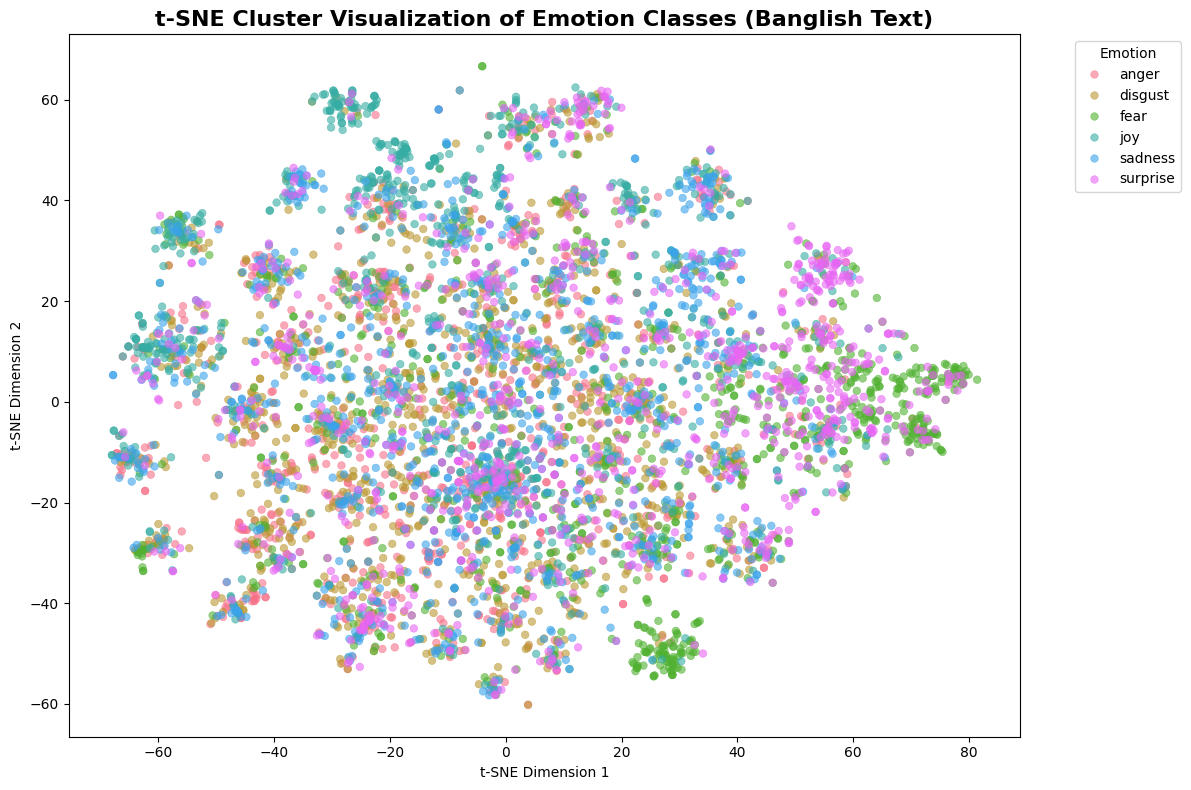

Visualization complete! Notice the degree of overlap versus separation.


In [ ]:
#Emotion Cluster Visualization using t-SNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("Sampling 6,000 records for fast cluster visualization...")
# Take a stratified sample to preserve class ratios without crashing RAM
sample_df = df.groupby('Label', group_keys=False).apply(lambda x: x.sample(n=1000, random_state=42) if len(x) > 1000 else x)

print("Extracting fast TF-IDF features for visualization...")
tfidf_vis = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_vis = tfidf_vis.fit_transform(sample_df['text_normalized'])

print("Reducing dimensions with TruncatedSVD (PCA) to 50 dimensions...")
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_vis)

print("Applying t-SNE to reduce to 2D for plotting (this takes a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_svd)

# Plotting the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=sample_df['Label'],
    palette='husl',
    alpha=0.6,
    s=30,
    edgecolor=None
)

plt.title('t-SNE Cluster Visualization of Emotion Classes (Banglish Text)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Visualization complete! Notice the degree of overlap versus separation.")


In [ ]:
#3D Interactive Cluster Visualization

import plotly.express as px
from sklearn.decomposition import TruncatedSVD

print("Reducing TF-IDF features to 3 dimensions using TruncatedSVD (PCA)...")
# We use SVD to directly extract the top 3 axes of maximum variance
svd_3d = TruncatedSVD(n_components=3, random_state=42)
X_svd_3d = svd_3d.fit_transform(X_vis)

# Add the 3D coordinates to a temporary dataframe for Plotly
plot_df = sample_df[['Banglish', 'Label']].copy()
plot_df['PC1'] = X_svd_3d[:, 0]
plot_df['PC2'] = X_svd_3d[:, 1]
plot_df['PC3'] = X_svd_3d[:, 2]

print("Generating Interactive 3D Plot...")
# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Label',
    hover_data=['Banglish'], # Hover over a point to see the actual text!
    color_discrete_sequence=px.colors.qualitative.Prism,
    opacity=0.6,
    title='Interactive 3D PCA of Emotion Clusters (Rotate to view depth)'
)

# Make the dots a bit smaller for better visibility
fig.update_traces(marker=dict(size=3))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Display the interactive plot
fig.show()


Reducing TF-IDF features to 3 dimensions using TruncatedSVD (PCA)...
Generating Interactive 3D Plot...


In [ ]:
#Train/Val/Test Split & Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from scipy.sparse import hstack, csr_matrix

# 1. Stratified Splits (80% Train, 10% Val, 10% Test)
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df['label_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_id'], random_state=42)

y_train = train_df['label_id'].values
y_val = val_df['label_id'].values
y_test = test_df['label_id'].values

print("--- Data Splits ---")
print(f"Train size: {len(train_df):,} | Val size: {len(val_df):,} | Test size: {len(test_df):,}")

# 2. Extract Banglish TF-IDF Features (Word + Char n-grams)
print("\nExtracting TF-IDF Features for Baselines...")
tfidf_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=30000)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=30000)

X_train_word = tfidf_word.fit_transform(train_df['text_normalized'].fillna(''))
X_test_word = tfidf_word.transform(test_df['text_normalized'].fillna(''))

X_train_char = tfidf_char.fit_transform(train_df['text_normalized'].fillna(''))
X_test_char = tfidf_char.transform(test_df['text_normalized'].fillna(''))

X_train_tfidf = hstack([X_train_word, X_train_char])
X_test_tfidf = hstack([X_test_word, X_test_char])

# 3. Build the Bengali Lexicon Feature Generator (Naive Bayes Probabilities)
print("Extracting 6-Dimensional Bengali Lexicon Features...")
lexicon_model = make_pipeline(
    TfidfVectorizer(analyzer='word', ngram_range=(1, 3), max_features=20000),
    MultinomialNB()
)
lexicon_model.fit(train_df['Bengali'].fillna(''), y_train)

# These 6D probability vectors will be fed into the PyTorch Dual-Stream model
lex_train = lexicon_model.predict_proba(train_df['Bengali'].fillna(''))
lex_val = lexicon_model.predict_proba(val_df['Bengali'].fillna(''))
lex_test = lexicon_model.predict_proba(test_df['Bengali'].fillna(''))

# Combined features for ML Baselines
X_train_combined = hstack([X_train_tfidf, csr_matrix(lex_train)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(lex_test)])

print("Feature Engineering Complete.")
print(f"Final ML Feature Vector Size: {X_train_combined.shape[1]:,} dimensions")


--- Data Splits ---
Train size: 64,069 | Val size: 8,009 | Test size: 8,009

Extracting TF-IDF Features for Baselines...
Extracting 6-Dimensional Bengali Lexicon Features...
Feature Engineering Complete.
Final ML Feature Vector Size: 60,006 dimensions


Training Linear SVM on 60,006 dimensions (This will take 1-2 minutes)...
Predicting on Test Set...

✅ SVM (TF-IDF + Lexicon) Weighted F1-Score: 0.5892

--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.45      0.45      0.45      1517
     disgust       0.49      0.50      0.50      1310
        fear       0.78      0.60      0.68       756
         joy       0.72      0.79      0.75      1784
     sadness       0.53      0.57      0.55      1631
    surprise       0.67      0.57      0.62      1011

    accuracy                           0.59      8009
   macro avg       0.61      0.58      0.59      8009
weighted avg       0.59      0.59      0.59      8009



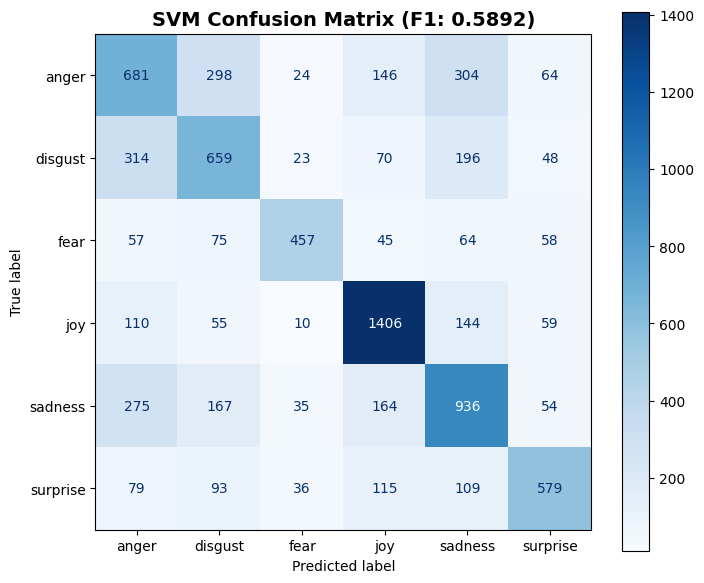

In [ ]:
#Baseline Model Evaluation (Linear SVM + Lexicon)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Training Linear SVM on 60,006 dimensions (This will take 1-2 minutes)...")

# We use class_weight='balanced' to force the model to pay attention to minority classes like Fear
base_svm = LinearSVC(max_iter=2000, class_weight='balanced', random_state=42)

# CalibratedClassifierCV
svm_lex = CalibratedClassifierCV(base_svm)
svm_lex.fit(X_train_combined, y_train)

print("Predicting on Test Set...")
y_pred_svm = svm_lex.predict(X_test_combined)

f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
print(f"\n✅ SVM (TF-IDF + Lexicon) Weighted F1-Score: {f1_svm:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=label_names))

#Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'SVM Confusion Matrix (F1: {f1_svm:.4f})', fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#Dual-Stream Tokenizers and PyTorch Dataset
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import torch

print("Downloading Tokenizers (XLM-R and BanglaBERT)...")
xlmr_tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
banglabert_tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')

class DualInputDataset(Dataset):
    def __init__(self, banglish_texts, bengali_texts, lexicon_features, labels,
                 xlmr_tokenizer, banglabert_tokenizer, max_len=128):
        self.banglish_texts = banglish_texts.reset_index(drop=True)
        self.bengali_texts = bengali_texts.reset_index(drop=True)
        self.lexicon_features = torch.tensor(lexicon_features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.xlmr_tokenizer = xlmr_tokenizer
        self.banglabert_tokenizer = banglabert_tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        banglish_text = str(self.banglish_texts[idx])
        bengali_text = str(self.bengali_texts[idx])

        encoding_a = self.xlmr_tokenizer(
            banglish_text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', return_attention_mask=True, truncation=True, return_tensors='pt'
        )

        encoding_b = self.banglabert_tokenizer(
            bengali_text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', return_attention_mask=True, truncation=True, return_tensors='pt'
        )

        return {
            'input_ids_a': encoding_a['input_ids'].flatten(),
            'attention_mask_a': encoding_a['attention_mask'].flatten(),
            'input_ids_b': encoding_b['input_ids'].flatten(),
            'attention_mask_b': encoding_b['attention_mask'].flatten(),
            'lexicon': self.lexicon_features[idx],
            'label': self.labels[idx]
        }

print("Packaging data into PyTorch DataLoaders...")
train_dataset = DualInputDataset(train_df['text_normalized'], train_df['Bengali'], lex_train, y_train, xlmr_tokenizer, banglabert_tokenizer)
val_dataset = DualInputDataset(val_df['text_normalized'], val_df['Bengali'], lex_val, y_val, xlmr_tokenizer, banglabert_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

batch = next(iter(train_loader))
print("\n--- DataLoader Verification ---")
print(f"Batch XLM-R Input Shape: {batch['input_ids_a'].shape}")
print(f"Batch BanglaBERT Input Shape: {batch['input_ids_b'].shape}")
print(f"Batch Lexicon Feature Shape: {batch['lexicon'].shape}")
print("Ready for modeling!")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Packaging data into PyTorch DataLoaders...

--- DataLoader Verification ---
Batch XLM-R Input Shape: torch.Size([16, 128])
Batch BanglaBERT Input Shape: torch.Size([16, 128])
Batch Lexicon Feature Shape: torch.Size([16, 6])
Ready for modeling!


In [ ]:
#PyTorch Architecture & Focal Loss Definition
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha.to(inputs.device) if self.alpha is not None else None)
        pt = torch.exp(-BCE_loss)
        F_loss = ((1 - pt) ** self.gamma) * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        return torch.sum(F_loss)

class DualStreamEmotionModel(nn.Module):
    def __init__(self, num_classes=6, lexicon_dim=6, dropout_rate=0.3):
        super(DualStreamEmotionModel, self).__init__()

        print("Initializing XLM-RoBERTa (Stream A)...")
        self.stream_a = AutoModel.from_pretrained('xlm-roberta-base')

        print("Initializing BanglaBERT (Stream B)...")
        self.stream_b = AutoModel.from_pretrained('csebuetnlp/banglabert')

        combined_dim = self.stream_a.config.hidden_size + self.stream_b.config.hidden_size + lexicon_dim

        print(f"Creating Classifier Head (Input Dim: {combined_dim})...")
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(combined_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids_a, attention_mask_a, input_ids_b, attention_mask_b, lexicon_features):
        # Pass through Stream A and grab the [CLS] token representation (shape: batch_size, 768)
        cls_a = self.stream_a(input_ids=input_ids_a, attention_mask=attention_mask_a).last_hidden_state[:, 0, :]

        # Pass through Stream B and grab the [CLS] token representation (shape: batch_size, 768)
        cls_b = self.stream_b(input_ids=input_ids_b, attention_mask=attention_mask_b).last_hidden_state[:, 0, :]

        # Concatenate Streams with Lexicon features
        combined_features = torch.cat((cls_a, cls_b, lexicon_features), dim=1)

        # Final classification
        logits = self.classifier(combined_features)
        return logits

print("\nLoading models to GPU...")
model = DualStreamEmotionModel(num_classes=6, lexicon_dim=6)
model = model.to(device)
print("✅ Architecture successfully loaded to GPU!")



Loading models to GPU...
Initializing XLM-RoBERTa (Stream A)...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initializing BanglaBERT (Stream B)...


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Creating Classifier Head (Input Dim: 1542)...
✅ Architecture successfully loaded to GPU!


In [ ]:
#PyTorch Training Loop
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

EPOCHS = 3

# 1. Compute Class Weights for Focal Loss
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f"Computed Class Weights: {class_weights}")

# 2. Setup Criterion, Optimizer, and Scheduler
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler() # For Mixed Precision Training

# 3. Training Loop
best_val_f1 = 0

for epoch in range(EPOCHS):
    print(f"\n======== Epoch {epoch+1} / {EPOCHS} ========")

    # --- TRAINING ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

    for batch in progress_bar:
        b_input_a = batch['input_ids_a'].to(device)
        b_mask_a = batch['attention_mask_a'].to(device)
        b_input_b = batch['input_ids_b'].to(device)
        b_mask_b = batch['attention_mask_b'].to(device)
        b_lexicon = batch['lexicon'].to(device)
        b_labels = batch['label'].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(b_input_a, b_mask_a, b_input_b, b_mask_b, b_lexicon)
            loss = criterion(logits, b_labels)

        total_train_loss += loss.item()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    print("Running Validation...")
    model.eval()
    total_val_loss = 0
    val_preds, val_true = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            b_input_a = batch['input_ids_a'].to(device)
            b_mask_a = batch['attention_mask_a'].to(device)
            b_input_b = batch['input_ids_b'].to(device)
            b_mask_b = batch['attention_mask_b'].to(device)
            b_lexicon = batch['lexicon'].to(device)
            b_labels = batch['label'].to(device)

            with torch.cuda.amp.autocast():
                logits = model(b_input_a, b_mask_a, b_input_b, b_mask_b, b_lexicon)
                loss = criterion(logits, b_labels)

            total_val_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(b_labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_f1 = f1_score(val_true, val_preds, average='weighted')

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1-Score: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), '/content/drive/My Drive/424 Project/Best_Dual_Stream_Model.pt')
        print(f"⭐ New Best Model Saved with F1: {val_f1:.4f}!")


Computed Class Weights: [0.87944051 1.01910352 1.76440295 0.74839968 0.81856395 1.32090137]

======== Epoch 1 / 3 ========


Training Epoch 1:   0%|          | 0/4005 [00:00<?, ?it/s]

Running Validation...


Validating:   0%|          | 0/501 [00:00<?, ?it/s]

Train Loss: 0.6851 | Val Loss: 0.5047 | Val F1-Score: 0.6459
⭐ New Best Model Saved with F1: 0.6459!

======== Epoch 2 / 3 ========


...

Train Loss: 0.3923 | Val Loss: 0.4623 | Val F1-Score: 0.6537
⭐ New Best Model Saved with F1: 0.6537!

======== Epoch 3 / 3 ========


Training Epoch 3:   0%|          | 0/4005 [00:00<?, ?it/s]

Running Validation...


Validating:   0%|          | 0/501 [00:00<?, ?it/s]

Train Loss: 0.2557 | Val Loss: 0.4858 | Val F1-Score: 0.6872
⭐ New Best Model Saved with F1: 0.6872!


Loading the Best Saved Model Weights...
Evaluating on Test Set...


Testing:   0%|          | 0/501 [00:00<?, ?it/s]


🏆 Final Dual-Stream Transformer Test F1-Score: 0.6948

--- Final Classification Report ---
              precision    recall  f1-score   support

       anger       0.58      0.59      0.59      1517
     disgust       0.64      0.67      0.66      1310
        fear       0.67      0.79      0.73       756
         joy       0.85      0.85      0.85      1784
     sadness       0.70      0.57      0.63      1631
    surprise       0.70      0.74      0.72      1011

    accuracy                           0.70      8009
   macro avg       0.69      0.70      0.69      8009
weighted avg       0.70      0.70      0.69      8009



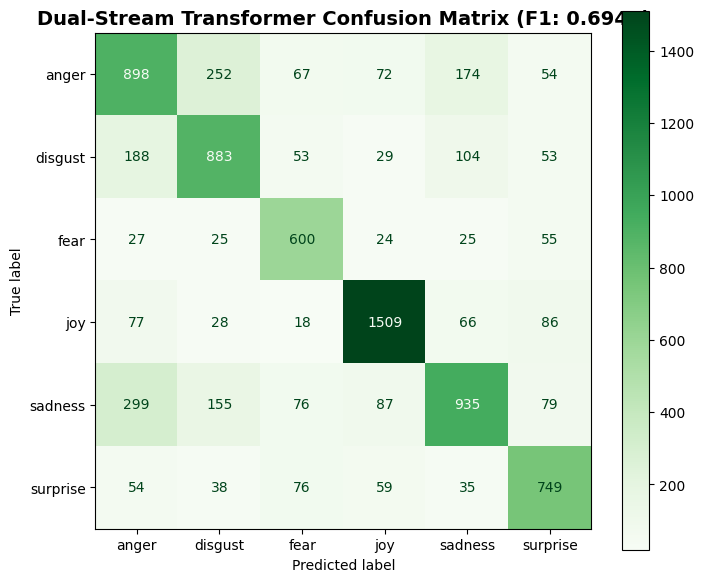

In [ ]:

#Final Evaluation on Held-Out Test Set

from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Loading the Best Saved Model Weights...")

model.load_state_dict(torch.load('/content/drive/My Drive/424 Project/Best_Dual_Stream_Model.pt'))

model.eval()

test_dataset = DualInputDataset(test_df['text_normalized'], test_df['Bengali'], lex_test, y_test, xlmr_tokenizer, banglabert_tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
test_preds, test_true = [], []

print("Evaluating on Test Set...")

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Testing"):
        b_input_a = batch['input_ids_a'].to(device)

        b_mask_a = batch['attention_mask_a'].to(device)

        b_input_b = batch['input_ids_b'].to(device)

        b_mask_b = batch['attention_mask_b'].to(device)

        b_lexicon = batch['lexicon'].to(device)

        b_labels = batch['label'].to(device)

        with torch.cuda.amp.autocast():
            logits = model(b_input_a, b_mask_a, b_input_b, b_mask_b, b_lexicon)

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_true.extend(b_labels.cpu().numpy())



final_f1 = f1_score(test_true, test_preds, average='weighted')

print(f"\n🏆 Final Dual-Stream Transformer Test F1-Score: {final_f1:.4f}\n")
print("--- Final Classification Report ---")
print(classification_report(test_true, test_preds, target_names=label_names))

# Plot Final Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'Dual-Stream Transformer Confusion Matrix (F1: {final_f1:.4f})', fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#Load Kaggle EmoNoBa Dataset
!pip install -q kagglehub
import kagglehub
import pandas as pd
import os

print("Downloading EmoNoBa dataset from Kaggle...")
path = kagglehub.dataset_download("saifsust/emonoba")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Files in dataset:", files)

data_file = [f for f in files if f.endswith('.csv') or f.endswith('.xlsx')][0]
full_path = os.path.join(path, data_file)

if data_file.endswith('.csv'):
    df_ext = pd.read_csv(full_path)
else:
    df_ext = pd.read_excel(full_path)

print(f"\nLoaded {len(df_ext)} rows from {data_file}.")
print("Columns found:", list(df_ext.columns))

print("\n--- First Row Preview ---")
print(df_ext.iloc[0].to_dict())

label_cols = [col for col in df_ext.columns if 'label' in col.lower() or 'emotion' in col.lower() or 'class' in col.lower()]
if label_cols:
    target_col = label_cols[0]
    print(f"\nUnique Labels in '{target_col}':")
    print(df_ext[target_col].value_counts())
else:
    print("\n⚠️ No obvious 'label' column found.")


100%|██████████| 1.10M/1.10M [00:00<00:00, 77.8MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/saifsust/emonoba/versions/1
Files in dataset: ['Train.csv', 'Test.csv', 'Val.csv']

Loaded 18420 rows from Train.csv.
Columns found: ['ID', 'Data', 'Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear', 'Topic', 'Domain', 'is_admin']

--- First Row Preview ---
{'ID': 5454, 'Data': 'লকাল বাস ভালো এটা থেকে ', 'Love': 0, 'Joy': 0, 'Surprise': 0, 'Anger': 0, 'Sadness': 1, 'Fear': 0, 'Topic': 'Travel', 'Domain': 'Youtube', 'is_admin': False}

⚠️ No obvious 'label' column found.


In [ ]:
#EmoNoBa Zero-Shot / Out-of-Domain Evaluation
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 1. Load the TEST split of EmoNoBa
test_path = os.path.join(path, 'Test.csv')
df_ext_test = pd.read_csv(test_path)
print(f"Loaded EmoNoBa Test Set: {len(df_ext_test)} rows")

# 2. Convert One-Hot to Single Label
emotion_cols = ['Joy', 'Surprise', 'Anger', 'Sadness', 'Fear'] # Excluding 'Love'

# Filter out rows where Love is the primary emotion (since our model wasn't trained on it)
df_ext_test = df_ext_test[df_ext_test['Love'] == 0].reset_index(drop=True)
print(f"Rows after removing 'Love' class: {len(df_ext_test)}")

# Get the column name with the max value (the true emotion)
df_ext_test['true_emotion'] = df_ext_test[emotion_cols].idxmax(axis=1).str.lower()

# Map to our model's label IDs
# (Assuming label_mapping is still in memory from Cell 3)
df_ext_test['label_id'] = df_ext_test['true_emotion'].map(label_mapping)

print("Running Dual-Stream Model on EmoNoBa...")

# 3. Predict Using our Trained Model
model.eval()
ext_preds, ext_true = [], []

# We only have Bengali text ('Data'), so we pass it to BOTH streams
ext_dataset = DualInputDataset(
    banglish_texts=df_ext_test['Data'], # Stream A (XLM-R) natively handles Bengali!
    bengali_texts=df_ext_test['Data'],  # Stream B (BanglaBERT)
    lexicon_features=lexicon_model.predict_proba(df_ext_test['Data'].fillna('')),
    labels=df_ext_test['label_id'].values,
    xlmr_tokenizer=xlmr_tokenizer,
    banglabert_tokenizer=banglabert_tokenizer
)

ext_loader = DataLoader(ext_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for batch in tqdm(ext_loader, desc="Evaluating EmoNoBa"):
        b_input_a = batch['input_ids_a'].to(device)
        b_mask_a = batch['attention_mask_a'].to(device)
        b_input_b = batch['input_ids_b'].to(device)
        b_mask_b = batch['attention_mask_b'].to(device)
        b_lexicon = batch['lexicon'].to(device)
        b_labels = batch['label'].to(device)

        with torch.cuda.amp.autocast():
            logits = model(b_input_a, b_mask_a, b_input_b, b_mask_b, b_lexicon)

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        ext_preds.extend(preds)
        ext_true.extend(b_labels.cpu().numpy())

# 4. Results
ext_f1 = f1_score(ext_true, ext_preds, average='weighted')
print(f"\n🌍 Out-of-Domain (EmoNoBa) F1-Score: {ext_f1:.4f}\n")

print("--- EmoNoBa Classification Report ---")
print(classification_report(
    ext_true,
    ext_preds,
    labels=list(label_mapping.values()),
    target_names=list(label_mapping.keys()),
    zero_division=0
))

Loaded EmoNoBa Test Set: 2272 rows
Rows after removing 'Love' class: 1884
Running Dual-Stream Model on EmoNoBa...


Evaluating EmoNoBa:   0%|          | 0/118 [00:00<?, ?it/s]


🌍 Out-of-Domain (EmoNoBa) F1-Score: 0.7017

--- EmoNoBa Classification Report ---
              precision    recall  f1-score   support

       anger       0.59      0.60      0.60       472
     disgust       0.00      0.00      0.00         0
        fear       0.49      0.76      0.60        51
         joy       0.89      0.87      0.88       774
     sadness       0.67      0.44      0.53       470
    surprise       0.55      0.80      0.66       117

    accuracy                           0.69      1884
   macro avg       0.53      0.58      0.54      1884
weighted avg       0.73      0.69      0.70      1884

